In [2]:
import os
from typing import Optional, List
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import seaborn as sns
from Utils import Notebook, tex, gph, sgn, nm, ds


sns.set_style("whitegrid")

Notebook.setup()

LaTeX has been enabled for text rendering.


In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import matplotlib as mpl
from typing import Optional


def plot_cycles_transition(df_filtered: pd.DataFrame, target_l: Optional[int] = None, output_dir: Optional[str] = None) -> None:
  """
  Generates professional heatmaps for cycle stability analysis.

  Includes cell bordering (grid) and specific coloring for zero-value 
  cells using a distinct 'under' color.
  """
  if df_filtered.empty:
    return

  unique_ls = df_filtered['l_word'].unique()

  if target_l is not None or len(unique_ls) <= 1:
    fig, ax = plt.subplots(figsize=(8, 6))
    data = df_filtered[df_filtered['l_word'] ==
                       target_l] if target_l else df_filtered

    sigma = data['sigma']
    stable = data['StableCycles']
    unstable = data['UnstableCycles']

    ax.bar(sigma, stable, width=0.02, color='green',
           alpha=0.7, label='Stable Cycles')
    ax.bar(sigma, unstable, width=0.02, bottom=stable,
           color='red', alpha=0.7, label='Unstable Cycles')

    current_l = target_l if target_l else unique_ls[0]
    ax.set_title(rf'Stability Transition (l={current_l})', fontsize=14)
    ax.set_xlabel(r'$\sigma$', fontsize=12)
    ax.set_ylabel('Number of Cycles', fontsize=12)
    ax.legend()
    ax.grid(True, linestyle='--', alpha=0.5)

  else:
    pivot_stable = df_filtered.pivot(
        index='l_word', columns='sigma', values='StableCycles')
    pivot_unstable = df_filtered.pivot(
        index='l_word', columns='sigma', values='UnstableCycles')

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 6), sharey=True)

    cmap_stable = mpl.colormaps['Greens'].copy()
    cmap_stable.set_under('#EAEAEA')

    cmap_unstable = mpl.colormaps['Reds'].copy()
    cmap_unstable.set_under('#EAEAEA')

    x = pivot_stable.columns.values
    y = pivot_stable.index.values

    # Grid is implemented via edgecolors and linewidth in pcolormesh
    grid_params = {
        'shading': 'auto',
        'edgecolors': 'white',
        'linewidth': 0.5,
        'vmin': 0.1
    }

    label_fontsize = 18

    im1 = ax1.pcolormesh(x, y, pivot_stable.values,
                         cmap=cmap_stable, **grid_params)
    ax1.set_title('Stable Cycles (Grey = 0)', fontsize=label_fontsize)
    ax1.set_xlabel(r'$\sigma$', fontsize=label_fontsize)
    ax1.set_ylabel(r'$l$', fontsize=label_fontsize)
    ax1.tick_params(labelsize=label_fontsize)
    cbar1 = fig.colorbar(im1, ax=ax1, extend='min')
    cbar1.set_label('Count', fontsize=label_fontsize)
    cbar1.ax.tick_params(labelsize=label_fontsize)

    im2 = ax2.pcolormesh(x, y, pivot_unstable.values,
                         cmap=cmap_unstable, **grid_params)
    ax2.set_title('Unstable Cycles (Grey = 0)', fontsize=label_fontsize)
    ax2.set_xlabel(r'$\sigma$', fontsize=label_fontsize)
    ax2.tick_params(labelsize=label_fontsize)
    cbar2 = fig.colorbar(im2, ax=ax2, extend='min')
    cbar2.set_label('Count', fontsize=label_fontsize)
    cbar2.ax.tick_params(labelsize=label_fontsize)

  plt.tight_layout()

  if output_dir:
    pass
  else:
    plt.show()

Dataset 'etc-traffic-logs/single_matrix/kmax30.csv' successfully loaded into memory.


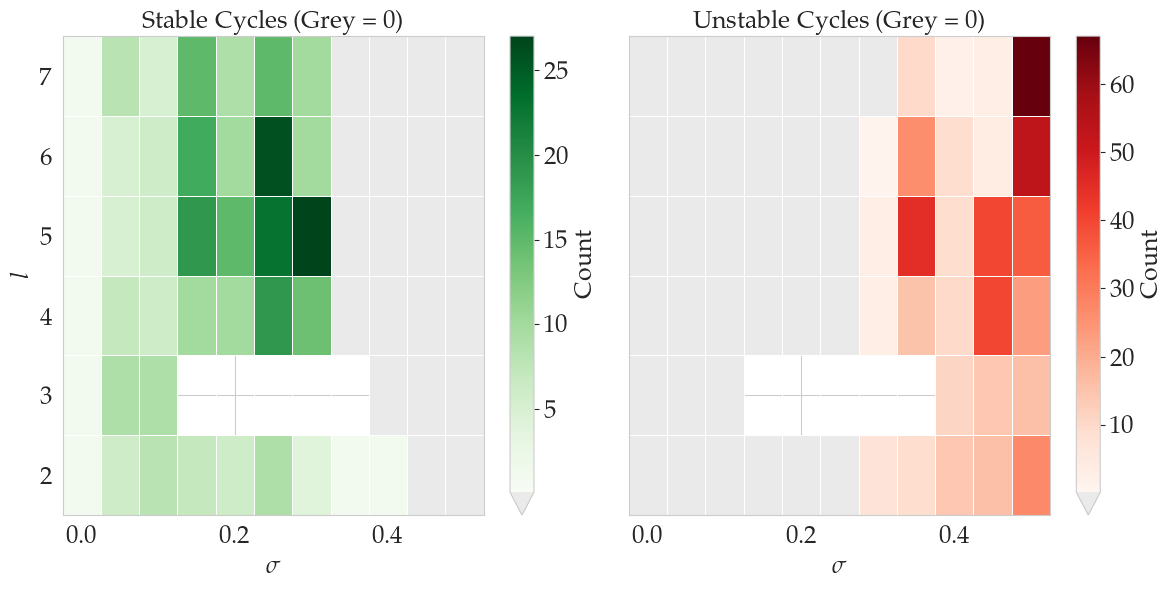

In [4]:
data_file_path: str = 'etc-traffic-logs/single_matrix/kmax30.csv'
target_l: int = 3
df_raw = pd.read_csv(data_file_path)
print(f"Dataset '{data_file_path}' successfully loaded into memory.")

df_filtered = df_raw[df_raw['l_word'] == target_l]
plot_cycles_transition(df_raw, None, output_dir=None)

In [22]:
import pandas as pd


def remover_linhas_por_valor(arquivo_entrada, arquivo_saida, coluna, valor_para_remover):
  """
  Remove linhas de um arquivo CSV onde a coluna especificada possui o valor exato.
  """
  # Carrega o arquivo CSV em um DataFrame
  df = pd.read_csv(arquivo_entrada)

  # Verifica se a coluna existe no arquivo
  if coluna not in df.columns:
    raise ValueError(f"A coluna '{coluna}' não foi encontrada no arquivo.")

  # Filtra mantendo apenas as linhas onde o valor da coluna é DIFERENTE do valor informado
  df_filtrado = df[df[coluna] != valor_para_remover]

  # Salva o resultado no novo arquivo CSV (sem adicionar uma coluna de índice)
  df_filtrado.to_csv(arquivo_saida, index=False)
  print(f"Arquivo salvo com sucesso em: {arquivo_saida}")


# Exemplo de uso:
remover_linhas_por_valor(
    data_file_path, 'dados_filtrados.csv', 'sigma', 0.0)

Arquivo salvo com sucesso em: dados_filtrados.csv


In [ ]:





def plot_traffic_savings(df_filtered: pd.DataFrame, target_l: int, output_dir: Optional[str] = None) -> None:
  """
  Generates a line plot with diamond markers for traffic savings.

  Args:
      df_filtered (pd.DataFrame): Filtered dataset containing savings data.
      target_l (int): The parameter l used for filtering.
      output_dir (Optional[str]): Directory path to save the generated plot.
  """
  if df_filtered.empty:
    return

  fig, ax = plt.subplots(figsize=(10, 6))

  sigma = df_filtered['sigma']
  savings = df_filtered['SavingsPct']

  ax.plot(sigma, savings, marker='D', markersize=8,
          color='orange', linestyle='-', linewidth=2)

  ax.set_title(
      rf'Traffic Savings vs. $\sigma$ (Comparison with Periodic h=0.05s) (for l={target_l})', fontsize=14)
  ax.set_xlabel(r'$\sigma$ (Parameter)', fontsize=12)
  ax.set_ylabel('Min Savings (%)', fontsize=12)
  ax.set_ylim(0, 100)
  ax.set_xticks(sigma)
  ax.xaxis.set_major_formatter(ticker.FormatStrFormatter('%.2f'))
  ax.grid(True, linestyle='--', alpha=0.5)

  plt.tight_layout()
  if output_dir:
    pass
  else:
    plt.show()


def plot_entropy(df_filtered: pd.DataFrame, target_l: int, output_dir: Optional[str] = None) -> None:
  """
  Generates a line plot for Behavioral Entropy against the sigma parameter.

  Args:
      df_filtered (pd.DataFrame): Filtered dataset containing 'sigma' and 'Entropy'.
      target_l (int): The parameter l used for filtering.
      output_dir (Optional[str]): Directory path to save the generated plot.

  Raises:
      KeyError: If 'Entropy' is missing from the DataFrame.
  """
  fig, ax = plt.subplots(figsize=(10, 6))

  sigma = df_filtered['sigma']
  entropy = df_filtered['Entropy']

  ax.plot(sigma, entropy, marker='s', color='tab:red',
          linestyle='--', linewidth=2, label='Entropy')

  ax.set_xlabel(r'$\sigma$ (Parameter)', fontsize=12)
  ax.set_ylabel(r'Entropy $h(S)$ [bits]', color='tab:red', fontsize=12)
  ax.tick_params(axis='y', labelcolor='tab:red')
  ax.set_xticks(sigma)
  ax.xaxis.set_major_formatter(ticker.FormatStrFormatter('%.2f'))

  ax.set_title(
      rf'Behavioral Entropy vs. $\sigma$ (l={target_l})', fontsize=14)
  ax.grid(True, linestyle='--', alpha=0.5)

  plt.tight_layout()

  if output_dir:
    pass
  else:
    plt.show()


def plot_limit_bounds(df_filtered: pd.DataFrame, target_l: int, output_dir: Optional[str] = None) -> None:
  """
  Generates a multi-line plot for system limit bounds and averages against the sigma parameter.

  Args:
      df_filtered (pd.DataFrame): Filtered dataset containing limit variables.
      target_l (int): The parameter l used for filtering.
      output_dir (Optional[str]): Directory path to save the generated plot.
  """
  fig, ax = plt.subplots(figsize=(12, 7))

  sigma = df_filtered['sigma']
  variables: List[str] = ['Inf', 'Sup', 'InfLimInf',
                          'SupLimSup', 'InfLimAvg', 'SupLimAvg']
  markers: List[str] = ['o', 's', '^', 'v', 'D', 'p']

  for var, marker in zip(variables, markers):
    ax.plot(sigma, df_filtered[var], marker=marker,
            linestyle='-', linewidth=1.5, label=var)

  ax.set_title(
      rf'System Limit Bounds vs. $\sigma$ (l={target_l})', fontsize=14)
  ax.set_xlabel(r'$\sigma$ (Parameter)', fontsize=12)
  ax.set_ylabel('Bound Values', fontsize=12)
  ax.set_xticks(sigma)
  ax.xaxis.set_major_formatter(ticker.FormatStrFormatter('%.2f'))

  ax.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
  plt.tight_layout()

  if output_dir:
    pass
  else:
    plt.show()

Dataset 'etc-traffic-logs/single_matrix/kmax5.csv' successfully loaded into memory.
Data subset extracted for l=2 (Yield: 19 records).
Initializing plot generation sequence for l=2...


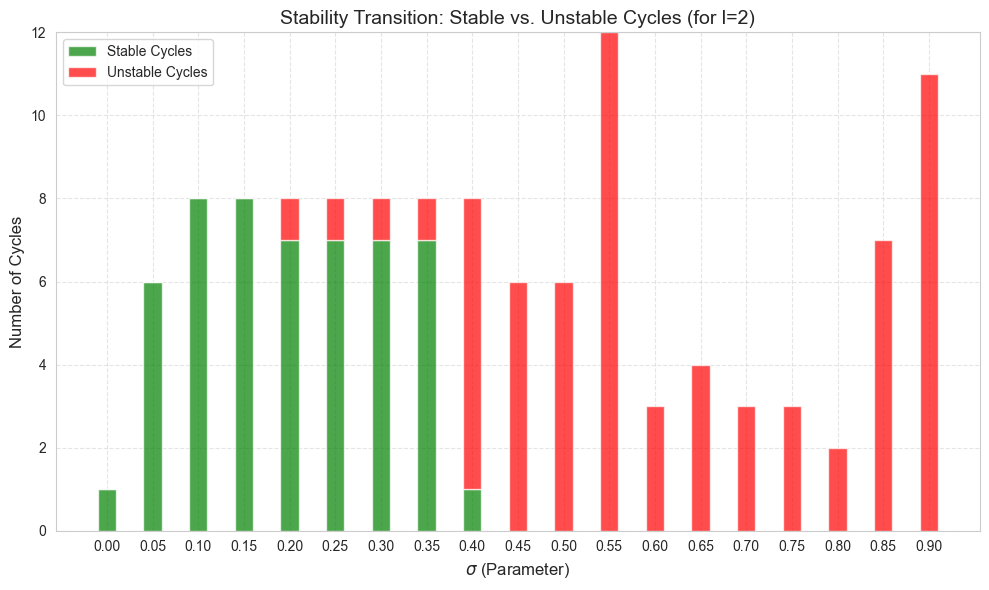

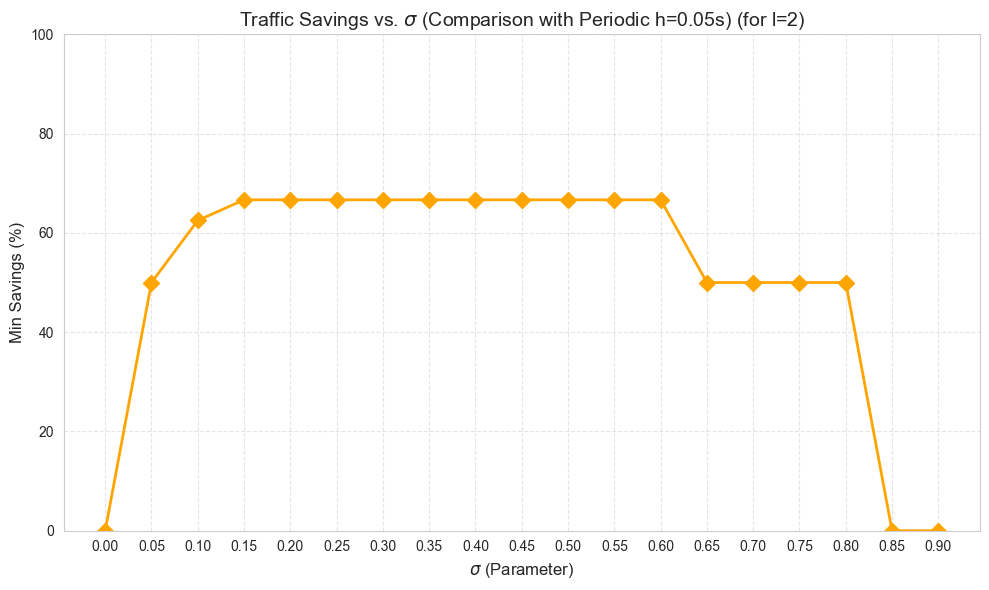

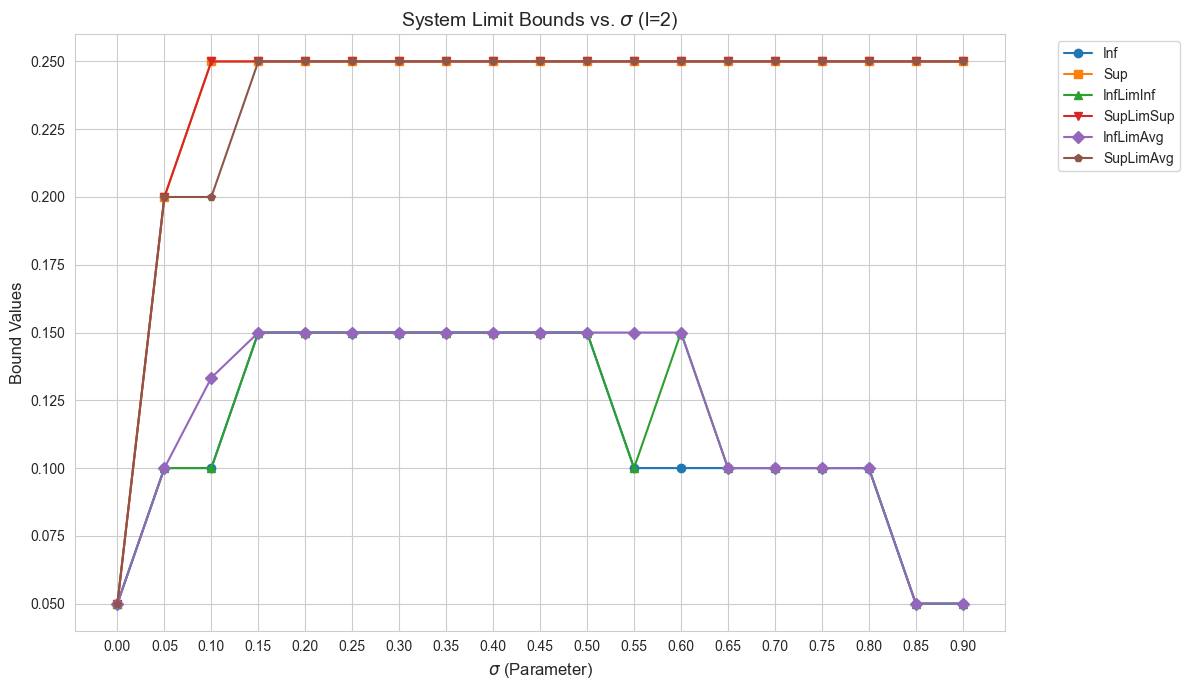

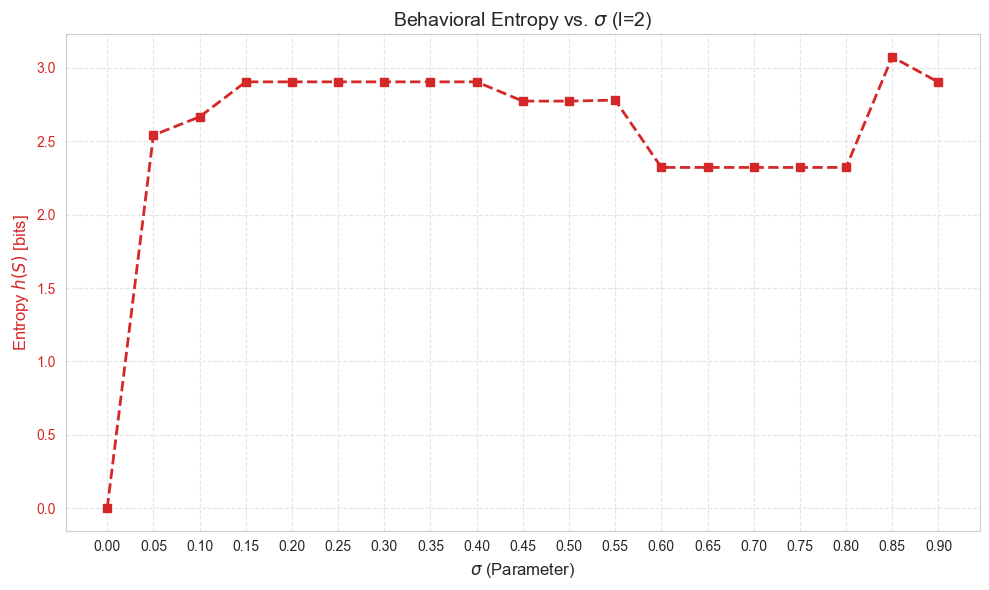

In [ ]:
"""
Execution cell for generating analytical plots based on system dynamics data.
Requires a valid CSV path and a target 'l_word' parameter for filtering.
"""
import os
import pandas as pd

# --- CONFIGURATION ---
data_file_path: str = 'etc-traffic-logs/single_matrix/kmax5.csv'
target_l: int = 2
# --- END CONFIGURATION ---

if not os.path.exists(data_file_path):
  print(
      f"Error: Target file '{data_file_path}' not found. Check your relative path.")
else:
  df_raw = pd.read_csv(data_file_path)
  print(f"Dataset '{data_file_path}' successfully loaded into memory.")

  df_filtered = df_raw[df_raw['l_word'] == target_l]
  print(
      f"Data subset extracted for l={target_l} (Yield: {len(df_filtered)} records).")

  if df_filtered.empty:
    print(
        f"Error: Data subset for l={target_l} is empty. Verify parameter existence in CSV.")
  else:
    print(f"Initializing plot generation sequence for l={target_l}...")

    plot_cycles_transition(df_filtered, target_l, output_dir=None)

    plot_traffic_savings(df_filtered, target_l, output_dir=None)

    plot_limit_bounds(df_filtered, target_l, output_dir=None)

    plot_entropy(df_filtered, target_l, output_dir=None)

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from typing import Optional


def plot_entropy_heatmap(df_raw: pd.DataFrame, output_dir: Optional[str] = None) -> None:
  """
  Generates a 2D heatmap projecting l_word (X-axis) and sigma (Y-axis), 
  encoding Behavioral Entropy as a color gradient to avoid 3D spatial occlusion.

  Args:
      df_raw (pd.DataFrame): The complete, unfiltered dataset.
      output_dir (Optional[str]): Directory path to save the generated plot.

  Raises:
      KeyError: If 'l_word', 'sigma', or 'Entropy' are missing from the DataFrame.
      ValueError: If the pivot operation fails due to dimensional mismatch.
  """
  entropy_matrix = df_raw.pivot_table(
      index='sigma',
      columns='l_word',
      values='Entropy',
      aggfunc='mean'
  )

  fig, ax = plt.subplots(figsize=(10, 8))

  sns.heatmap(
      data=entropy_matrix,
      cmap='viridis',
      annot=False,
      cbar_kws={'label': r'Entropy $h(S)$ [bits]'},
      ax=ax
  )

  ax.invert_yaxis()

  ax.set_xlabel(r'$l$ (Word Length)', fontsize=12, labelpad=10)
  ax.set_ylabel(r'$\sigma$ (Parameter)', fontsize=12, labelpad=10)
  ax.set_title(r'Behavioral Entropy Heatmap: $l$ vs $\sigma$',
               fontsize=14, pad=20)

  plt.tight_layout()

  if output_dir:
    pass
  else:
    plt.show()

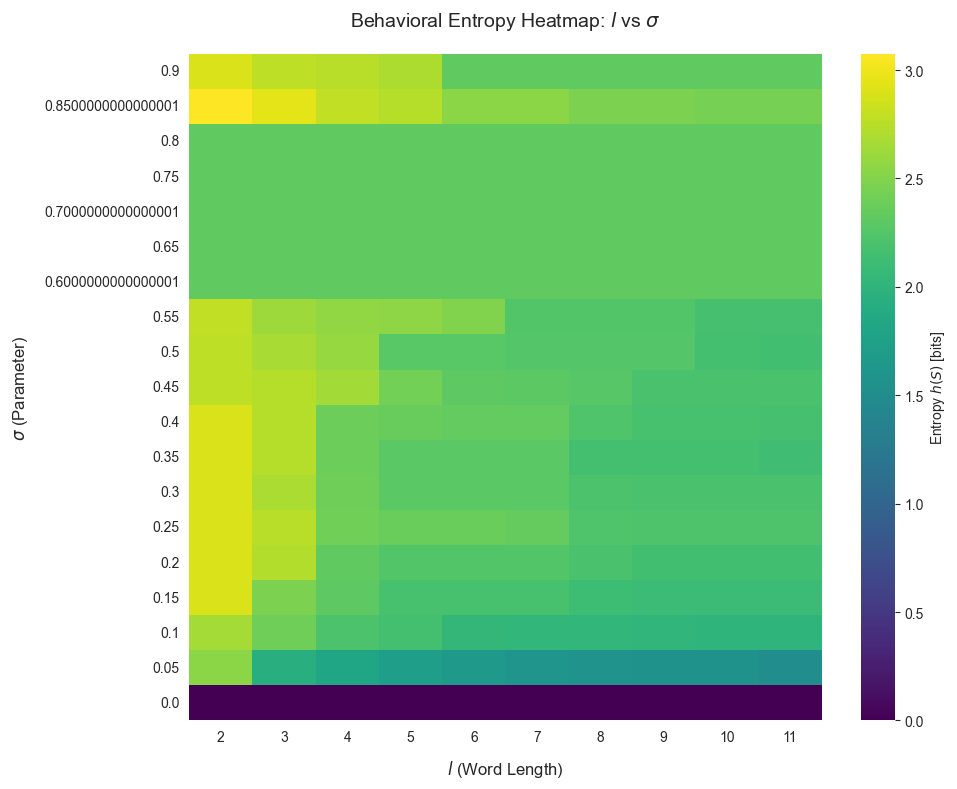

In [ ]:
plot_entropy_heatmap(df_raw)